# Installing Additional Libraries

In [18]:
!pip install monai -q

# Importing Libraries

In [19]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
import timm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from monai.losses import FocalLoss


from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.gridspec as gridspec

# Set random seeds for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    
seed_everything(42)

# Global Constants
DATA_DIR = "/kaggle/input/datasets/spark2025/spark-2026-chestxray/dataset"
IMG_SIZE = 380
BATCH_SIZE = 32
NUM_CLASSES = 2
EPOCHS = 30
LEARNING_RATE = 1e-4


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported succesfully!")

Using Device: cuda
Libraries imported succesfully!


# Data Augementation

In [20]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Data augmentation for training to improve model generalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),           # Randomly flip horizontally
    transforms.RandomRotation(15),                    # Slight rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Brightness & Contrast
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4818, 0.4818, 0.4818],
        std=[0.2223, 0.2223, 0.2223]
    )
])

# Standard transforms for validation and testing (No Augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
        transforms.Normalize(
        mean=[0.4818, 0.4818, 0.4818],
        std=[0.2223, 0.2223, 0.2223]
    )
])

print("Transforms Initialized")


Transforms Initialized


In [21]:
train_dir = os.path.join(DATA_DIR, 'train')
val_dir   = os.path.join(DATA_DIR, 'val')

train_dataset = ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = ImageFolder(root=val_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)

# Count class frequencies in training set
train_labels = [label for _, label in train_dataset]
num_normal = train_labels.count(0)
num_pneumonia = train_labels.count(1)
pos_weight = torch.tensor([num_normal / num_pneumonia]).to(DEVICE)
print(f"pos_weight = {pos_weight.item():.4f}")


val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
CLASS_NAMES = train_dataset.classes
print(f"DataLoaders built successfully, Classes: {CLASS_NAMES}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

print(train_dataset.class_to_idx)

pos_weight = 0.3704
DataLoaders built successfully, Classes: ['NORMAL', 'PNEUMONIA']
Train batches: 129 | Val batches: 28
{'NORMAL': 0, 'PNEUMONIA': 1}


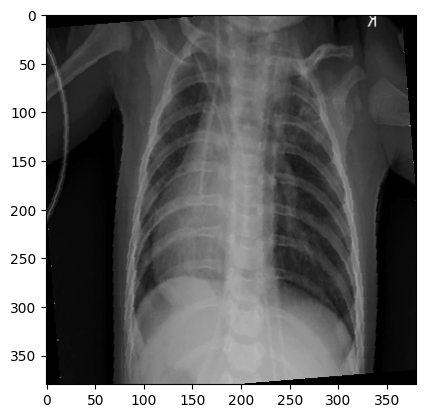

In [22]:
image, label = next(iter(train_loader))
plt.imshow(image[1, 0, :, :], cmap="gray")

# Model Architecture

In [23]:
class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model('densenet121', pretrained=True, num_classes=2)

        in_features = self.backbone.classifier.in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [24]:
model = DenseNetClassifier()

In [25]:
# Unfreeze classifier head
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

# Unfreeze DenseNet denseblock4 as well
for name, param in model.backbone.named_parameters():
    if "denseblock4" in name:
        param.requires_grad = True

x = model(torch.randn(1, 3, 380, 380))
print(x.shape)

torch.Size([1, 2])


# Model Training

In [26]:
from torch.amp import autocast, GradScaler


# criterion = FocalLoss(gamma=2.0, alpha=0.25, to_onehot_y=True, use_softmax=True, reduction="mean")
scaler = GradScaler(device="cuda")


def calculate_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

def train_model(model, name="densenet_classifier"):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    early_stop_patience = 5
    epochs_no_improve = 0


    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0]).to(DEVICE), label_smoothing=0.1)
    
    print(f"Starting training for {name}")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
    
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Training - {name}]", leave=False):
            images = images.to(DEVICE)
            labels = labels.long().to(DEVICE)
    
            optimizer.zero_grad()
    
            with autocast(device_type='cuda'):
                outputs = model(images)                 # [B, 2]
                loss = criterion(outputs, labels)
    
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
    
            running_loss += loss.item()
    
        train_loss = running_loss / len(train_loader)
    
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
    
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Validating - {name}]", leave=False):
                images = images.to(DEVICE)
                labels = labels.long().to(DEVICE)
    
                with autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
    
                val_loss += loss.item()
                val_acc += calculate_accuracy(outputs, labels)
    
        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
    
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
    
        scheduler.step(val_loss)
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'{name}_best.pth')
            print(f" >>> Best model saved! (Val Loss: {val_loss:.4f})")
        else:
            epochs_no_improve += 1
            print(f"   --- No improvement for {epochs_no_improve}/{early_stop_patience} epochs.")
            if epochs_no_improve >= early_stop_patience:
                print(f"\n EARLY STOPPING at Epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}")
                break

    return history
    
    print(f"Training Complete for {name}")

In [27]:
model.to(DEVICE)
history = train_model(model=model)

Starting training for densenet_classifier


Epoch 1/3 [Training - densenet_classifier]:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 1/3 [Validating - densenet_classifier]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch [1/3] | Train Loss: 0.2785 | Val Loss: 0.2325 | Val Acc: 0.9654
 >>> Best model saved! (Val Loss: 0.2325)


Epoch 2/3 [Training - densenet_classifier]:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 2/3 [Validating - densenet_classifier]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch [2/3] | Train Loss: 0.2084 | Val Loss: 0.2296 | Val Acc: 0.9643
 >>> Best model saved! (Val Loss: 0.2296)


Epoch 3/3 [Training - densenet_classifier]:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 3/3 [Validating - densenet_classifier]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch [3/3] | Train Loss: 0.2002 | Val Loss: 0.2149 | Val Acc: 0.9699
 >>> Best model saved! (Val Loss: 0.2149)


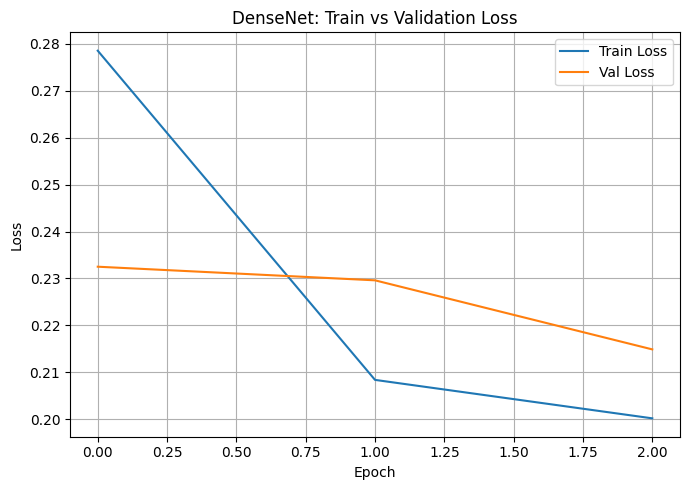

In [28]:

def plot_train_vs_val(history, model_name="Model"):
    plt.figure(figsize=(7, 5))

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")

    plt.title(f"{model_name}: Train vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_train_vs_val(history, "DenseNet")

# Validation

Starting validation...

 Evaluating: densenet_classifier
Loaded weights for densenet_classifier


Evaluating densenet_classifier:   0%|          | 0/28 [00:00<?, ?it/s]

-----------------------------------------------------
 densenet_classifier RESULTS
-----------------------------------------------------
Macro F1-Score : 0.9605
AUC-ROC        : 0.9967
              precision    recall  f1-score   support

      NORMAL       0.96      0.92      0.94       237
   PNEUMONIA       0.97      0.99      0.98       641

    accuracy                           0.97       878
   macro avg       0.97      0.96      0.96       878
weighted avg       0.97      0.97      0.97       878



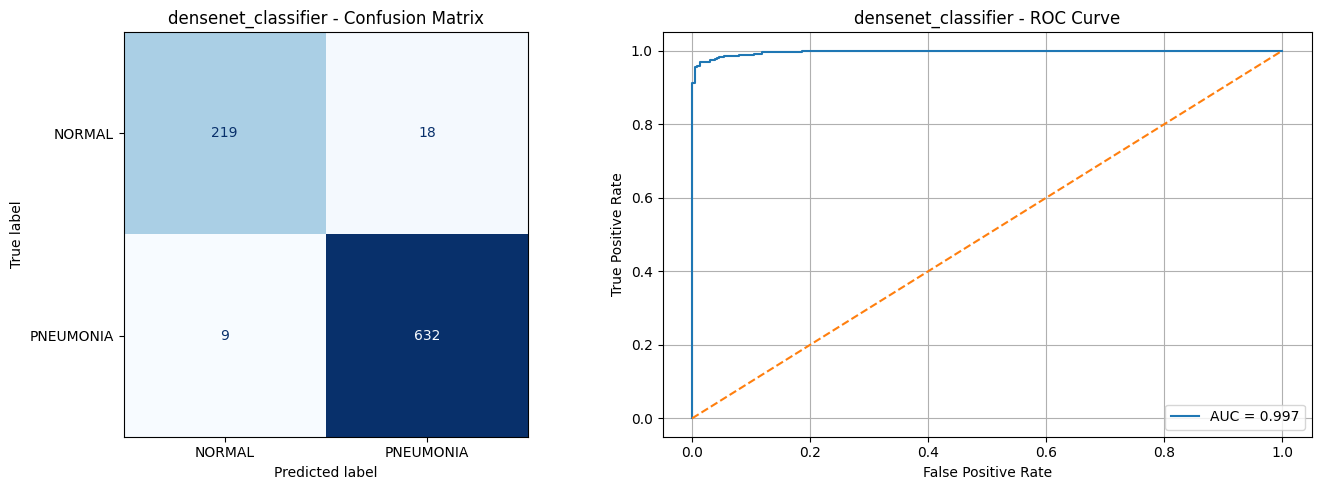

In [30]:
print("Starting validation...")

results = {}
base_path = "/kaggle/working/"
name = "densenet_classifier"

print("\n==============================")
print(f" Evaluating: {name}")
print("==============================")

try:
    # Load best checkpoint
    ckpt_path = os.path.join(base_path, f"{name}_best.pth")

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print(f"Loaded weights for {name}")
    else:
        print("Checkpoint not found. Using current model weights.")

    model = model.to(DEVICE)
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    # Validation loop
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Evaluating {name}"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with autocast(device_type="cuda"):
                logits = model(images)
                probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    # Convert to numpy
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Metrics
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    try:
        auc_score = roc_auc_score(all_labels, all_probs)
    except:
        auc_score = float("nan")

    cm = confusion_matrix(all_labels, all_preds)

    print("-----------------------------------------------------")
    print(f" {name} RESULTS")
    print("-----------------------------------------------------")
    print(f"Macro F1-Score : {f1_macro:.4f}")
    print(f"AUC-ROC        : {auc_score:.4f}")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=CLASS_NAMES,
        zero_division=0
    ))

    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    ).plot(ax=axes[0], cmap="Blues", colorbar=False)

    axes[0].set_title(f"{name} - Confusion Matrix")

    if not np.isnan(auc_score):
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        axes[1].plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
        axes[1].plot([0, 1], [0, 1], "--")
        axes[1].set_title(f"{name} - ROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend()
        axes[1].grid(True)
    else:
        axes[1].text(0.5, 0.5, "ROC not available",
                     ha="center", va="center")
        axes[1].set_title("ROC Curve")

    plt.tight_layout()
    plt.show()

    # Save results
    results[name] = {
        "f1": f1_macro,
        "auc": auc_score
    }

except Exception as e:
    print(f"{name} evaluation failed: {e}")

# Generating predictions

In [31]:
print("Generating Predictions...")

test_csv_path = os.path.join(DATA_DIR, "test.csv")
submission_df = pd.read_csv(test_csv_path)

name = "densenet_classifier"

print("\n==============================")
print(f" Predicting with: {name}")
print("==============================")

try:
    # Load best model
    ckpt_path = f"{name}_best.pth"

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print(f"Loaded {ckpt_path}")
    else:
        print("Checkpoint not found. Using current model weights.")

    model = model.to(DEVICE)
    model.eval()

    predictions = []

    with torch.no_grad():
        for _, row in tqdm(
            submission_df.iterrows(),
            total=len(submission_df),
            desc="Generating Predictions"
        ):
            img_path = os.path.join(DATA_DIR, row["filepath"])

            img = Image.open(img_path).convert("RGB")
            img_tensor = val_test_transform(img).unsqueeze(0).to(DEVICE)

            with autocast(device_type="cuda"):
                logits = model(img_tensor)
                probs = torch.softmax(logits, dim=1)

            pred = torch.argmax(probs, dim=1).item()
            predictions.append(pred)

    # Save submission
    out_df = submission_df.copy()
    out_df["target"] = predictions
    out_df = out_df[["id", "target"]]

    out_path = f"submission_{name}.csv"
    out_df.to_csv(out_path, index=False)

    print(f"Saved {out_path}")
    print(out_df.head())

except Exception as e:
    print(f"Prediction failed: {e}")

Generating Predictions...

 Predicting with: densenet_classifier
[INFO] Loaded densenet_classifier_best.pth


Generating Predictions:   0%|          | 0/879 [00:00<?, ?it/s]

Saved submission_densenet_classifier.csv
          id  target
0  CXR_05741       1
1  CXR_03646       1
2  CXR_00870       1
3  CXR_04969       1
4  CXR_01893       1
